<a href="https://colab.research.google.com/github/navyasreeg2025-bot/eda-lab-experiment/blob/main/Exp_6_01_09_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
from tensorflow.keras.datasets import mnist

# This line does the actual downloading (happens once, cached after)
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [31]:
print("Train images shape:", X_train.shape)
print("Train labels shape:", y_train.shape)
print("Test images shape :", X_test.shape)
print("Test labels shape :", y_test.shape)

Train images shape: (60000, 28, 28)
Train labels shape: (60000,)
Test images shape : (10000, 28, 28)
Test labels shape : (10000,)


In [32]:
#Part A: Data Understanding and Preprocessing
#1)Download and load the MNIST dataset.
#2)Display:Number of samples,Number of classes,Image dimensions
import numpy as np
import matplotlib.pyplot as plt
import time
import pandas as pd

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

np.random.seed(42)

from tensorflow.keras.datasets import mnist
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = mnist.load_data()

X = np.concatenate([X_train_raw, X_test_raw], axis=0)
y = np.concatenate([y_train_raw, y_test_raw], axis=0)

print("Number of samples :", X.shape[0])
print("Number of classes :", len(np.unique(y)))
print("Image dimensions  :", X.shape[1], "x", X.shape[2], "pixels")
print("Pixel value range :", X.min(), "to", X.max())

Number of samples : 70000
Number of classes : 10
Image dimensions  : 28 x 28 pixels
Pixel value range : 0 to 255


In [33]:
# Flatten: (60000, 28, 28) -> (60000, 784)
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

X_train_norm = X_train_flat.astype('float32') / 255.0
X_test_norm = X_test_flat.astype('float32') / 255.0

print("X_train_norm shape:", X_train_norm.shape)
print("X_test_norm shape :", X_test_norm.shape)

X_train_norm shape: (60000, 784)
X_test_norm shape : (10000, 784)


In [34]:
from sklearn.neighbors import KNeighborsClassifier
import time
n_sample = 5000
X_train_small = X_train_norm[:n_sample]
y_train_small = y_train[:n_sample]

n_test_sample = 1000
X_test_small = X_test_norm[:n_test_sample]
y_test_small = y_test[:n_test_sample]

model = KNeighborsClassifier(n_neighbors=3)

start = time.time()
model.fit(X_train_small, y_train_small)
train_time = time.time() - start

start = time.time()
predictions = model.predict(X_test_small)
predict_time = time.time() - start

print("Predictions on first 10 test samples:", predictions[:10])
print("Training time  : %.3f sec" % train_time)
print("Prediction time: %.3f sec" % predict_time)

Predictions on first 10 test samples: [7 2 1 0 4 1 4 9 5 9]
Training time  : 0.005 sec
Prediction time: 0.462 sec


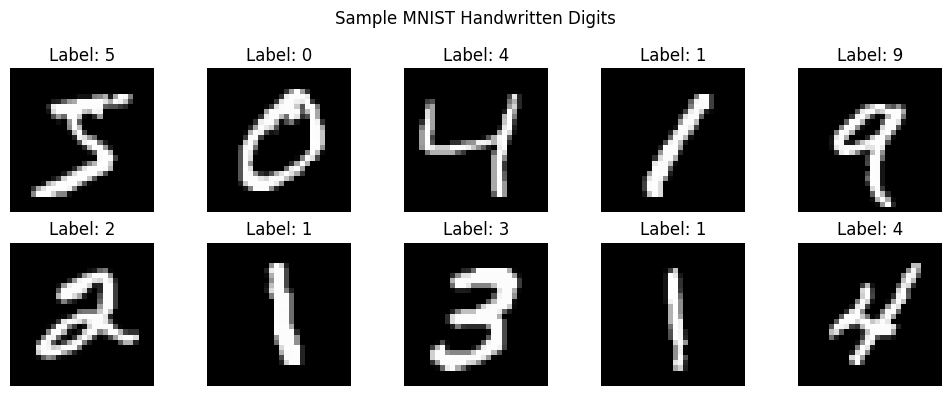

In [35]:
#3)Visualize at least 10 sample handwritten digit images.
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X[i], cmap='gray')
    plt.title(f"Label: {y[i]}")
    plt.axis('off')
plt.suptitle("Sample MNIST Handwritten Digits")
plt.tight_layout()
plt.show()

In [8]:
#4)Normalize pixel values to the range [0,1].
X_flat = X.reshape(X.shape[0], -1)
X_norm = X_flat.astype('float32') / 255.0
print("Flattened + normalized shape:", X_norm.shape)
print("New min/max:", X_norm.min(), X_norm.max())

Flattened + normalized shape: (70000, 784)
New min/max: 0.0 1.0


In [12]:
# Part B: Principal Component Analysis (PCA)
#5)Apply PCA on the dataset.
#6)Determine: Variance explained by each principal component.
n_sample = 10000
idx = np.random.choice(X_norm.shape[0], n_sample, replace=False)
X_sub = X_norm[idx]
y_sub = y[idx]

pca_full = PCA(n_components=784, random_state=42)
pca_full.fit(X_sub)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)
def components_for_variance(cum_var, threshold):
    return np.argmax(cum_var >= threshold) + 1

n_90 = components_for_variance(cumulative_var, 0.90)
n_95 = components_for_variance(cumulative_var, 0.95)
n_99 = components_for_variance(cumulative_var, 0.99)

print(f"Components needed for 90% variance: {n_90}")
print(f"Components needed for 95% variance: {n_95}")
print(f"Components needed for 99% variance: {n_99}")

Components needed for 90% variance: 86
Components needed for 95% variance: 151
Components needed for 99% variance: 325


In [13]:
#7)Reduce the dataset to:2 dimensions, 50 dimensions
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_sub)

pca_50d = PCA(n_components=50, random_state=42)
X_pca_50d = pca_50d.fit_transform(X_sub)

print("2D shape :", X_pca_2d.shape)
print("50D shape:", X_pca_50d.shape)

2D shape : (10000, 2)
50D shape: (10000, 50)


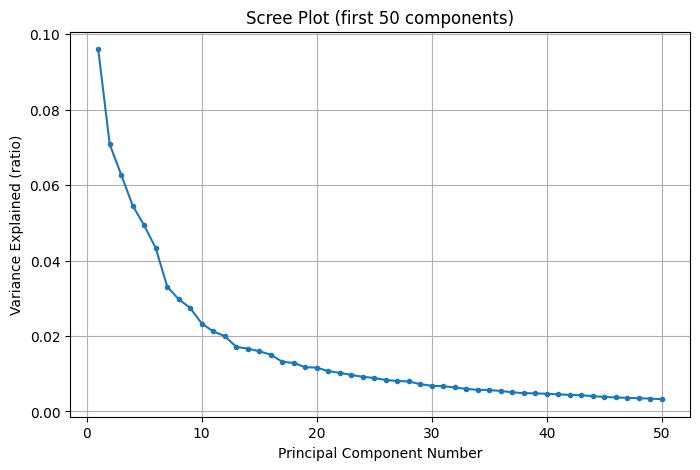

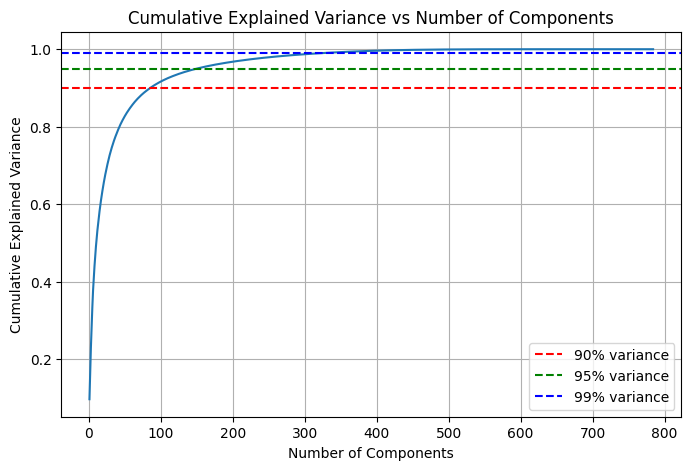

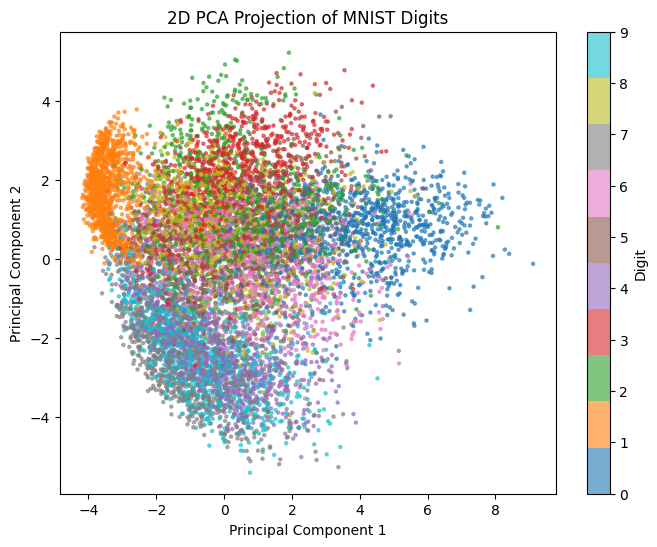

In [36]:
#8)Plot: Scree Plot, Cumulative Explained Variance Plot, 2D PCA Projection
plt.figure(figsize=(8, 5))
plt.plot(range(1, 51), explained_var[:50], marker='o', markersize=3)
plt.xlabel("Principal Component Number")
plt.ylabel("Variance Explained (ratio)")
plt.title("Scree Plot (first 50 components)")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(range(1, 785), cumulative_var)
plt.axhline(y=0.90, color='r', linestyle='--', label='90% variance')
plt.axhline(y=0.95, color='g', linestyle='--', label='95% variance')
plt.axhline(y=0.99, color='b', linestyle='--', label='99% variance')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance vs Number of Components")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y_sub, cmap='tab10', s=5, alpha=0.6)
plt.colorbar(scatter, label='Digit')
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("2D PCA Projection of MNIST Digits")
plt.show()

t-SNE on raw 784-dim data took: 20.29 sec
t-SNE on PCA-50D data took: 17.26 sec


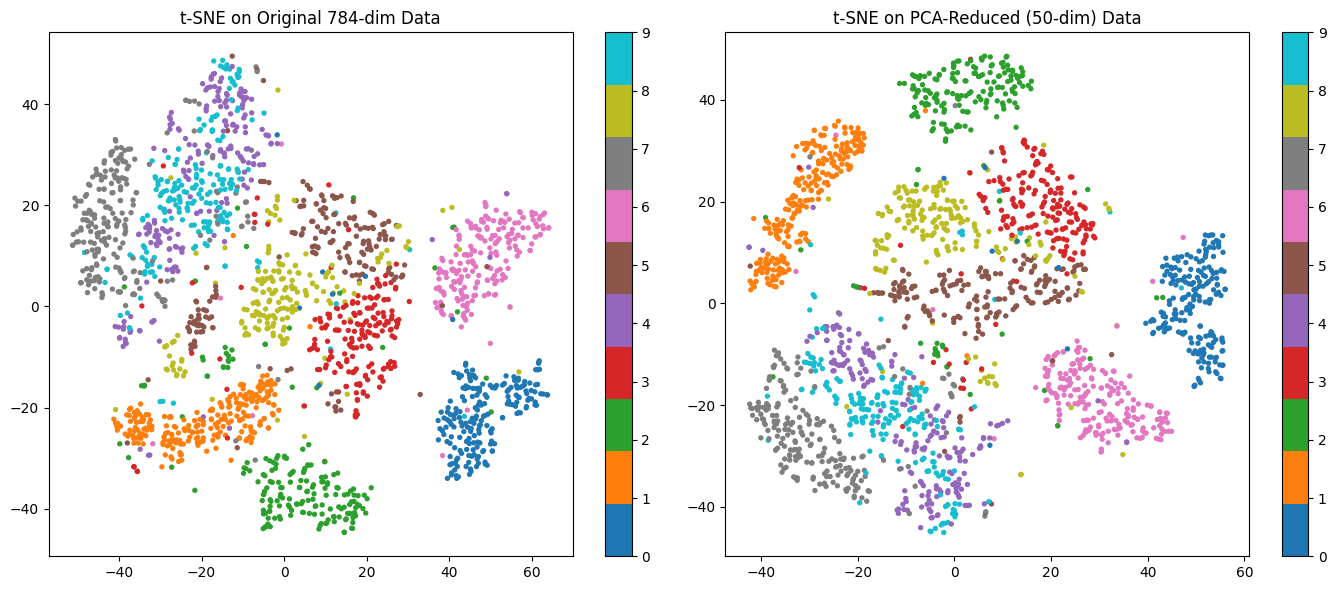

In [37]:
#Part C: t-SNE Visualization
#9)Applying t-SNE
#10)Generate a 2D visualization showing the clustering of handwritten digits.
n_tsne = 2000
idx_tsne = np.random.choice(X_sub.shape[0], n_tsne, replace=False)

X_tsne_input_raw = X_sub[idx_tsne]
X_tsne_input_pca = X_pca_50d[idx_tsne]
y_tsne = y_sub[idx_tsne]
start = time.time()
tsne_raw = TSNE(n_components=2, perplexity=30, random_state=42, init='pca')
X_tsne_raw_2d = tsne_raw.fit_transform(X_tsne_input_raw)
print("t-SNE on raw 784-dim data took: %.2f sec" % (time.time() - start))
start = time.time()
tsne_pca = TSNE(n_components=2, perplexity=30, random_state=42, init='pca')
X_tsne_pca_2d = tsne_pca.fit_transform(X_tsne_input_pca)
print("t-SNE on PCA-50D data took: %.2f sec" % (time.time() - start))
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sc1 = axes[0].scatter(X_tsne_raw_2d[:,0], X_tsne_raw_2d[:,1], c=y_tsne, cmap='tab10', s=8)
axes[0].set_title("t-SNE on Original 784-dim Data")
fig.colorbar(sc1, ax=axes[0])

sc2 = axes[1].scatter(X_tsne_pca_2d[:,0], X_tsne_pca_2d[:,1], c=y_tsne, cmap='tab10', s=8)
axes[1].set_title("t-SNE on PCA-Reduced (50-dim) Data")
fig.colorbar(sc2, ax=axes[1])
plt.tight_layout()
plt.show()

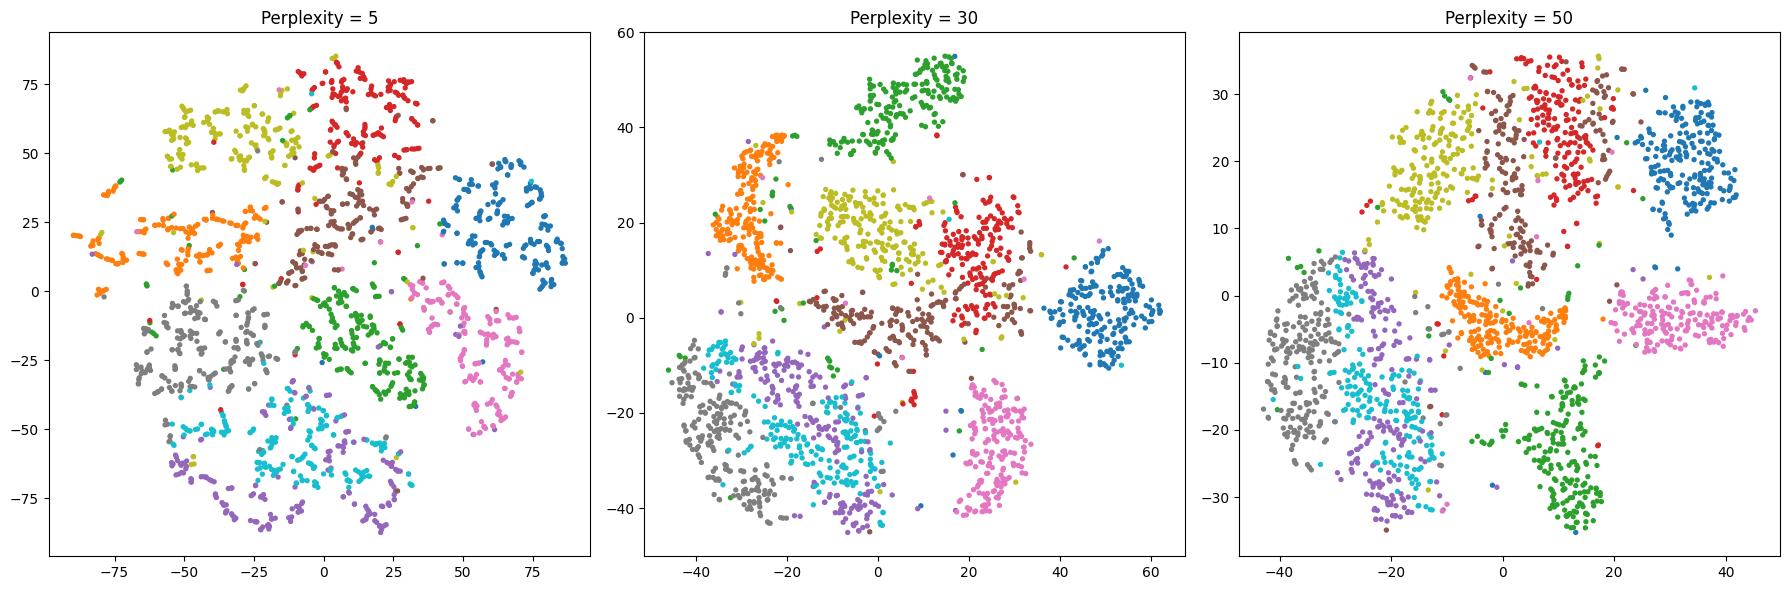

In [16]:
#11)Experiment with different perplexity values.
#12)Compare the resulting visualizations.
perplexities = [5, 30, 50]
fig, axes = plt.subplots(1, len(perplexities), figsize=(6*len(perplexities), 6))

for ax, perp in zip(axes, perplexities):
    tsne_model = TSNE(n_components=2, perplexity=perp, random_state=42, init='pca')
    X_embedded = tsne_model.fit_transform(X_tsne_input_pca)
    sc = ax.scatter(X_embedded[:,0], X_embedded[:,1], c=y_tsne, cmap='tab10', s=8)
    ax.set_title(f"Perplexity = {perp}")

plt.tight_layout()
plt.show()

In [25]:
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train_norm, y_train)
model.predict(X_test_norm)

array([7, 2, 1, ..., 4, 5, 6], dtype=uint8)

In [38]:
#13)
#14)
X_train_raw, X_test_raw_c, y_train_c, y_test_c = train_test_split(
    X_sub, y_sub, test_size=0.2, random_state=42, stratify=y_sub)
X_train_pca, X_test_pca_c, _, _ = train_test_split(
    X_pca_50d, y_sub, test_size=0.2, random_state=42, stratify=y_sub)

def evaluate_classifier(X_train, X_test, y_train, y_test, label):
    model = KNeighborsClassifier(n_neighbors=3)

    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    start = time.time()
    y_pred = model.predict(X_test)
    predict_time = time.time() - start

    acc = accuracy_score(y_test, y_pred)

    print(f"--- {label} ---")
    print(f"Accuracy       : {acc:.4f}")
    print(f"Training time  : {train_time:.3f} sec")
    print(f"Prediction time: {predict_time:.3f} sec\n")

    return acc, train_time, predict_time

results_raw = evaluate_classifier(X_train_raw, X_test_raw_c, y_train_c, y_test_c, "Original 784-dim")
results_pca = evaluate_classifier(X_train_pca, X_test_pca_c, y_train_c, y_test_c, "PCA 50-dim")

comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Training Time (s)", "Prediction Time (s)"],
    "Original (784-dim)": results_raw,
    "PCA (50-dim)": results_pca})
print(comparison)

--- Original 784-dim ---
Accuracy       : 0.9460
Training time  : 0.006 sec
Prediction time: 1.544 sec

--- PCA 50-dim ---
Accuracy       : 0.9570
Training time  : 0.002 sec
Prediction time: 0.210 sec

                Metric  Original (784-dim)  PCA (50-dim)
0             Accuracy            0.946000      0.957000
1    Training Time (s)            0.005995      0.002185
2  Prediction Time (s)            1.543532      0.210426


In [39]:
#15: Analyze how dimensionality reduction affects performance

acc_raw, train_time_raw, predict_time_raw = results_raw
acc_pca, train_time_pca, predict_time_pca = results_pca

acc_diff = (acc_pca - acc_raw) * 100
train_speedup = train_time_raw / train_time_pca
predict_speedup = predict_time_raw / predict_time_pca

print("="*60)
print("ANALYSIS: Effect of Dimensionality Reduction on Performance")
print("="*60)

print(f"\n1) ACCURACY:")
print(f"   Original (784-dim) Accuracy : {acc_raw:.4f}")
print(f"   PCA (50-dim) Accuracy       : {acc_pca:.4f}")
if acc_diff > 0:
    print(f"   -> PCA-reduced data gave {acc_diff:.2f} percentage points HIGHER accuracy.")
elif acc_diff < 0:
    print(f"   -> PCA-reduced data gave {abs(acc_diff):.2f} percentage points LOWER accuracy.")
else:
    print(f"   -> Both gave identical accuracy.")

print(f"\n2) TRAINING TIME:")
print(f"   Original (784-dim): {train_time_raw:.4f} sec")
print(f"   PCA (50-dim)      : {train_time_pca:.4f} sec")
print(f"   -> PCA training was {train_speedup:.2f}x faster than original data.")

print(f"\n3) PREDICTION TIME:")
print(f"   Original (784-dim): {predict_time_raw:.4f} sec")
print(f"   PCA (50-dim)      : {predict_time_pca:.4f} sec")
print(f"   -> PCA prediction was {predict_speedup:.2f}x faster than original data.")

print(f"\n4) CONCLUSION:")
print(f"   PCA reduced the feature space from 784 to 50 dimensions (a "
      f"{(1 - 50/784)*100:.1f}% reduction) while keeping accuracy "
      f"{'nearly the same' if abs(acc_diff) < 1 else ('higher' if acc_diff > 0 else 'slightly lower')}.")
print(f"   This confirms most class-discriminative information in MNIST digits")
print(f"   is captured within far fewer dimensions, and dimensionality reduction")
print(f"   gives a strong speed-accuracy tradeoff -- valuable for real-time or")
print(f"   large-scale digit recognition systems.")

ANALYSIS: Effect of Dimensionality Reduction on Performance

1) ACCURACY:
   Original (784-dim) Accuracy : 0.9460
   PCA (50-dim) Accuracy       : 0.9570
   -> PCA-reduced data gave 1.10 percentage points HIGHER accuracy.

2) TRAINING TIME:
   Original (784-dim): 0.0060 sec
   PCA (50-dim)      : 0.0022 sec
   -> PCA training was 2.74x faster than original data.

3) PREDICTION TIME:
   Original (784-dim): 1.5435 sec
   PCA (50-dim)      : 0.2104 sec
   -> PCA prediction was 7.34x faster than original data.

4) CONCLUSION:
   PCA reduced the feature space from 784 to 50 dimensions (a 93.6% reduction) while keeping accuracy higher.
   This confirms most class-discriminative information in MNIST digits
   is captured within far fewer dimensions, and dimensionality reduction
   gives a strong speed-accuracy tradeoff -- valuable for real-time or
   large-scale digit recognition systems.


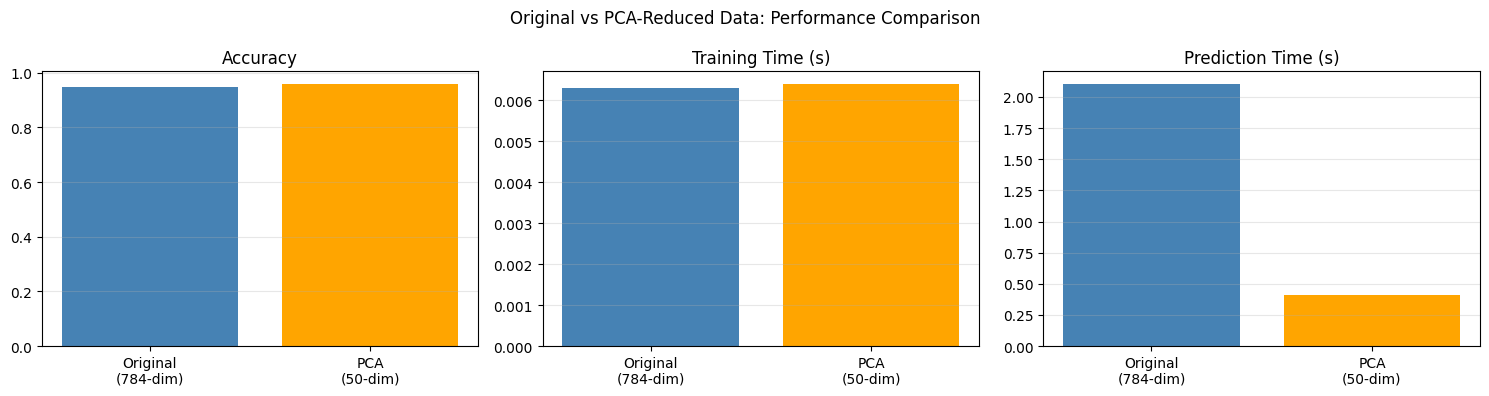

In [28]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ['Accuracy', 'Training Time (s)', 'Prediction Time (s)']
raw_values = [acc_raw, train_time_raw, predict_time_raw]
pca_values = [acc_pca, train_time_pca, predict_time_pca]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, (ax, metric) in enumerate(zip(axes, metrics)):
    ax.bar(['Original\n(784-dim)', 'PCA\n(50-dim)'], [raw_values[i], pca_values[i]],
           color=['steelblue', 'orange'])
    ax.set_title(metric)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle("Original vs PCA-Reduced Data: Performance Comparison")
plt.tight_layout()
plt.show()